# 05 · Econometric models: GARCH, GJR-GARCH and HAR

The baselines of Step 5 use fixed rules. The models of this step have **parameters estimated from the data**, and they are the standard tools of financial econometrics:

| Model | Input | Idea |
|---|---|---|
| **GARCH(1,1)** | Daily returns | Tomorrow's variance = long-run level + reaction to today's shock + memory of today's variance |
| **GJR-GARCH** | Daily returns | GARCH with a stronger reaction to *negative* returns (leverage effect) |
| **HAR** | Range-based variance | Linear regression on the volatility of the last day, week and month |
| **HAR-X** | All features of Step 4 | HAR plus leverage, market-wide volatility, VIX... still linear |

All four go through the walk-forward backtest of Step 5 and are re-estimated for every test year.

**Run first** (from the project root, a few minutes):
```bash
python -m src.data.setup_db            # adds the model_parameters table
python -m src.models.run_econometric
```

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from src.db import get_engine
from src.evaluation.metrics import abs_error_vol, qlike
from src.viz import AQUA, BLUE, CRISES, GRID, INK, INK_2, MUTED, ORANGE, save, set_style

set_style()
engine = get_engine()
pd.set_option("display.width", 180)
pd.set_option("display.float_format", "{:,.3f}".format)

LABELS = {"naive": "Naive (last value)", "monthly_average": "Monthly average", "historical_mean": "Historical mean",
          "ewma": "EWMA of range-based variance", "riskmetrics": "RiskMetrics (EWMA of squared returns)",
          "garch": "GARCH(1,1)", "gjr_garch": "GJR-GARCH", "har": "HAR", "har_x": "HAR-X"}

parameters = pd.read_sql("SELECT * FROM model_parameters", engine, parse_dates=["train_end"])
# most recent fit of each horizon (the training window ends h days before the 2026 test year)
last_fit = parameters[parameters["train_end"] == parameters.groupby("horizon")["train_end"].transform("max")]

## 1. GARCH and GJR-GARCH

GARCH = *Generalized Autoregressive Conditional Heteroskedasticity*: the variance changes over time (heteroskedasticity) and depends on its own past (autoregressive).

> variance(t+1) = ω + α · return(t)² + β · variance(t)   (+ γ · return(t)² if return(t) < 0, for GJR-GARCH)

* **α** is the reaction to today's shock, **β** the memory of today's variance, **γ** the extra reaction to a fall.
* **α + β (+ γ/2)** is the *persistence*: the share of a shock that survives to the next day. The closer to 1, the longer a shock lasts.
* **ω** pulls the variance back to its long-run level; forecasts for longer horizons revert towards that level.

With ω = 0, α = 0.06 and β = 0.94, GARCH is exactly the RiskMetrics baseline. GARCH **estimates** these numbers for each series, by maximum likelihood on its daily returns ([`src/models/garch.py`](../src/models/garch.py)).

The table shows the parameters of the most recent fit (returns up to the end of 2025), across the 59 series.

In [4]:
garch_last = last_fit[(last_fit["horizon"] == 1) & last_fit["model"].isin(["garch", "gjr_garch"])]
wide = garch_last.pivot(index=["model", "series"], columns="parameter", values="value")
wide["half_life_days"] = np.log(0.5) / np.log(wide["persistence"])

summary = wide.groupby("model")[["alpha", "gamma", "beta", "persistence", "half_life_days"]].median()
summary.loc["riskmetrics (fixed)"] = [0.06, 0.0, 0.94, 1.0, np.inf]
display(summary.rename(index=LABELS).rename_axis("median across series"))

parameter,alpha,gamma,beta,persistence,half_life_days
median across series,,,,,
"GARCH(1,1)",0.079,0.000,0.903,0.985,46.797
GJR-GARCH,0.020,0.081,0.909,0.984,43.276
riskmetrics (fixed),0.060,0.000,0.940,1.000,inf


**Reading the table.**

* The estimated GARCH is close to RiskMetrics, with one key difference: its persistence is slightly **below 1**, so volatility is expected to return to its long-run level. The *half-life* is the number of days after which half of a shock has faded.
* In GJR-GARCH, **γ is larger than α**: for a typical series, a fall moves the variance much more than a rise of the same size. For many series α is close to zero, meaning that only falls matter. This is the leverage effect found in the exploratory analysis.

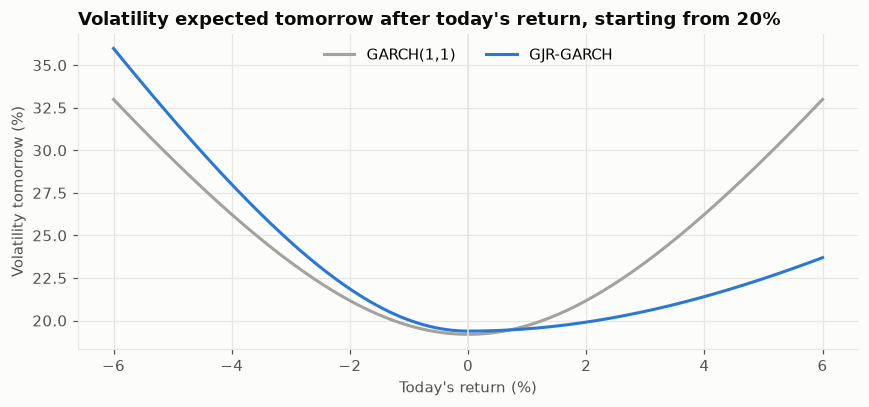

Series for which a fall has more than twice the impact of a rise (gamma > alpha): 90%


In [5]:
# News impact curve: tomorrow's volatility as a function of today's return.
# Both models start from the same situation: a volatility of 20%, equal to the long-run level.
typical = wide.groupby("model")[["alpha", "gamma", "beta"]].median()
returns = np.linspace(-6, 6, 241)                                   # today's return, in %
today = 20 ** 2 / 252                                               # daily variance, in %², for a 20% volatility

fig, ax = plt.subplots(figsize=(8, 3.8))
for model, color in [("garch", MUTED), ("gjr_garch", BLUE)]:
    p = typical.loc[model]
    omega = today * (1 - p["alpha"] - 0.5 * p["gamma"] - p["beta"])
    variance = omega + (p["alpha"] + p["gamma"] * (returns < 0)) * returns ** 2 + p["beta"] * today
    ax.plot(returns, np.sqrt(variance * 252), color=color, lw=2, label=LABELS[model])
ax.axvline(0, color=GRID, lw=1)
ax.set_xlabel("Today's return (%)")
ax.set_ylabel("Volatility tomorrow (%)")
ax.set_title("Volatility expected tomorrow after today's return, starting from 20%")
ax.legend(loc="upper center", ncols=2)
fig.tight_layout()
save(fig, "06_news_impact")
plt.show()

share = (wide.loc["gjr_garch", "gamma"] > wide.loc["gjr_garch", "alpha"]).mean()
print(f"Series for which a fall has more than twice the impact of a rise (gamma > alpha): {share:.0%}")

## 2. HAR

HAR = *Heterogeneous Autoregressive* model (Corsi, 2009). It is a plain linear regression:

> log variance(next h days) = a + b_day · log_rv_d + b_week · log_rv_w + b_month · log_rv_m

The three terms stand for three types of investors (daily, weekly, monthly horizon). Despite its simplicity, it is the reference model of the academic literature on realised volatility. Unlike GARCH, it is fed with the **range-based variance** of Step 4, and it is estimated **pooled**: one regression for all 59 series ([`src/models/har.py`](../src/models/har.py)).

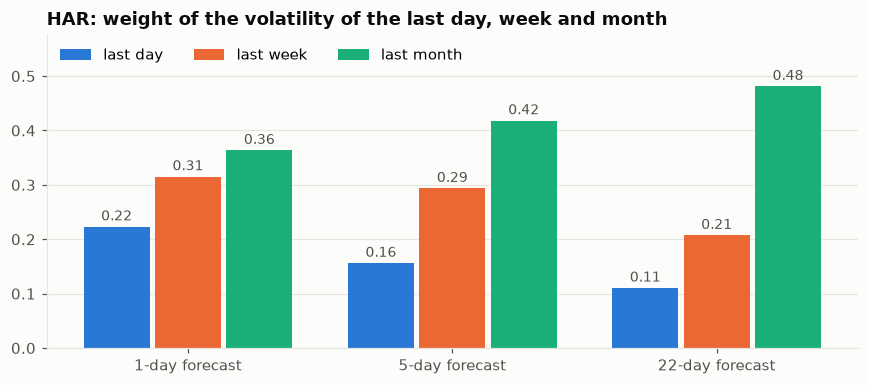

parameter,R² (training),correction factor,training rows
horizon,,,
1,0.539,1.480,"375,987.000"
5,0.650,1.259,"375,729.000"
22,0.639,1.222,"374,505.000"


In [6]:
har_last = last_fit[last_fit["model"] == "har"].pivot(index="horizon", columns="parameter", values="value")
coefs = har_last[["log_rv_d", "log_rv_w", "log_rv_m"]].rename(columns={"log_rv_d": "last day", "log_rv_w": "last week", "log_rv_m": "last month"})

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(coefs))
for i, (name, color) in enumerate(zip(coefs.columns, [BLUE, ORANGE, AQUA])):
    bars = ax.bar(x + (i - 1) * 0.27, coefs[name], width=0.25, color=color, label=name)
    for xi, v in zip(x + (i - 1) * 0.27, coefs[name]):
        ax.text(xi, v + 0.012, f"{v:.2f}", ha="center", color=INK_2, fontsize=9)
ax.set_xticks(x, [f"{h}-day forecast" for h in coefs.index])
ax.grid(axis="x", visible=False)
ax.set_ylim(0, coefs.max().max() * 1.2)
ax.set_title("HAR: weight of the volatility of the last day, week and month")
ax.legend(loc="upper left", ncols=3)
fig.tight_layout()
save(fig, "06_har_coefficients")
plt.show()

display(har_last[["r2", "smearing_factor", "n_train"]].rename(columns={"r2": "R² (training)", "smearing_factor": "correction factor", "n_train": "training rows"}))

**Reading the chart.**

* The three weights add up to 0.8 to 0.9: volatility is highly persistent, as in GARCH, but not fully, so forecasts revert towards an average level.
* The **longer the horizon, the more the last month matters** and the less the last day does: a single day says little about the average of the next 22 days.
* Even for a one-day forecast, the last day gets a small weight: a single day's variance is too noisy to be trusted alone, which is why the naive baseline fails at that horizon.

### From log variance to variance: a necessary correction

The regression predicts the **logarithm** of the variance. Taking the exponential of that prediction gives the *median* of the future variance, not its *mean*, because the variance is right-skewed: its mean lies above its median. Without a correction the model under-predicts risk on average, which QLIKE penalises heavily.

The forecast is therefore multiplied by a **correction factor**, the average of exp(residual) in the training sample (Duan's smearing estimator, about 1.2 here). The table compares the HAR forecasts with and without it, at the 5-day horizon.

In [7]:
har5 = pd.read_sql("""
    SELECT f.date, f.har::float8 AS forecast, exp(x.target_5d) AS actual
    FROM forecasts f JOIN features x USING (ticker, date)
    WHERE f.horizon = 5 AND f.har IS NOT NULL AND x.target_5d IS NOT NULL""", engine, parse_dates=["date"])
factors = parameters[(parameters["model"] == "har") & (parameters["horizon"] == 5) & (parameters["parameter"] == "smearing_factor")]
factor_by_year = factors.assign(test_year=factors["train_end"].dt.year + 1).set_index("test_year")["value"]
har5["uncorrected"] = har5["forecast"] / har5["date"].dt.year.map(factor_by_year)

display(pd.DataFrame({
    "QLIKE": [qlike(har5["actual"], har5[c]).mean() for c in ("uncorrected", "forecast")],
    "MAE (vol points)": [abs_error_vol(har5["actual"], har5[c]).mean() for c in ("uncorrected", "forecast")],
    "average of actual / forecast": [(har5["actual"] / har5[c]).mean() for c in ("uncorrected", "forecast")],
}, index=["exp(predicted log): forecasts the median", "with correction factor: forecasts the mean"]))

,QLIKE,MAE (vol points),average of actual / forecast
exp(predicted log): forecasts the median,0.267,6.292,1.243
with correction factor: forecasts the mean,0.242,7.005,1.010


The correction lowers QLIKE (the primary loss) and brings the average of actual / forecast close to 1, i.e. the forecast is right *on average*. It **raises** the mean absolute error: MAE rewards forecasts of the median, QLIKE forecasts of the mean. The two losses reward different targets, which is why one primary loss had to be chosen before comparing models (Step 5).

## 3. HAR-X: adding the other features

HAR-X is the same pooled regression with the 14 other numerical features of Step 4. Because the features have different units, the table shows the effect on the forecast of a **one-standard-deviation increase** of each feature, in %, for the 5-day horizon (most recent fit).

In [8]:
features = [p for p in last_fit.loc[last_fit["model"] == "har_x", "parameter"].unique()
            if p not in ("intercept", "r2", "smearing_factor", "n_train")]
std = pd.read_sql("SELECT " + ", ".join(f"stddev({f}) AS {f}" for f in features) + " FROM features", engine).iloc[0]
harx5 = last_fit[(last_fit["model"] == "har_x") & (last_fit["horizon"] == 5)].set_index("parameter")["value"]

effects = pd.DataFrame({"coefficient": harx5[features], "std of feature": std[features]})
effects["effect of +1 std on forecast variance (%)"] = (np.exp(effects["coefficient"] * effects["std of feature"]) - 1) * 100
print(f"R² in training: HAR {har_last.loc[5, 'r2']:.3f}, HAR-X {harx5['r2']:.3f}")
display(effects.sort_values("effect of +1 std on forecast variance (%)", key=abs, ascending=False))

R² in training: HAR 0.650, HAR-X 0.692


,coefficient,std of feature,effect of +1 std on forecast variance (%)
log_rv_m,0.353,0.951,39.946
log_rv_q,0.225,0.896,22.297
mkt_log_rv_m,-0.290,0.654,-17.297
mkt_log_rv_w,0.218,0.709,16.681
log_rv_w,0.145,1.034,16.236
log_rv_lt,0.148,0.596,9.237
mkt_log_rv_d,0.096,0.770,7.678
log_rv_d,0.055,1.194,6.838
log_vix,0.187,0.353,6.833
vol_of_vol_m,-0.299,0.216,-6.254


**Reading the table.**

* The own volatility of the last month and quarter remains the main driver, and the **long-run level** of each series now enters: forecasts revert to it, as in GARCH.
* **Returns matter, with a negative sign:** after a fall (and after a falling week or month) the forecast is higher. This is the leverage effect, here captured in a linear model.
* **The VIX and the market-wide volatility of the last week** add information beyond the series' own history: volatility is partly a common, market-wide phenomenon.
* Some coefficients have opposite signs within a group (e.g. market volatility of the week and of the month): the features are strongly correlated, so individual coefficients should not be over-interpreted. Step 7 uses SHAP values for a more reliable attribution.

## 4. Results

All nine models, scored in SQL on their common sample (2006 to 2026).

In [9]:
overall = pd.read_sql("SELECT * FROM model_scores_overall", engine)
overall["model_label"] = overall["model"].map(LABELS)
print(f"Forecasts per model and horizon: about {overall['n_forecasts'].median():,.0f}")

def table(metric):
    t = overall.pivot(index="model_label", columns="horizon", values=metric)
    t.columns = [f"{h} day" + ("s" if h > 1 else "") for h in t.columns]
    return t.sort_values(t.columns[1])

print("\nQLIKE (lower is better)")
display(table("qlike"))
print("MAE in annualised volatility points")
display(table("mae_vol"))

Forecasts per model and horizon: about 306,931

QLIKE (lower is better)


,1 day,5 days,22 days
model_label,,,
HAR-X,0.378,0.220,0.199
HAR,0.400,0.242,0.212
GJR-GARCH,0.431,0.262,0.222
"GARCH(1,1)",0.441,0.271,0.226
EWMA of range-based variance,0.440,0.273,0.250
Monthly average,0.468,0.302,0.281
RiskMetrics (EWMA of squared returns),0.478,0.317,0.298
Naive (last value),0.781,0.324,0.281
Historical mean,0.728,0.528,0.414


MAE in annualised volatility points


,1 day,5 days,22 days
model_label,,,
HAR-X,8.126,6.409,6.236
HAR,8.641,7.007,6.742
EWMA of range-based variance,8.951,7.121,6.608
GJR-GARCH,8.976,7.250,6.791
RiskMetrics (EWMA of squared returns),8.867,7.250,6.910
Naive (last value),9.339,7.289,6.970
"GARCH(1,1)",9.120,7.382,6.873
Monthly average,9.104,7.389,6.970
Historical mean,15.174,13.244,11.918


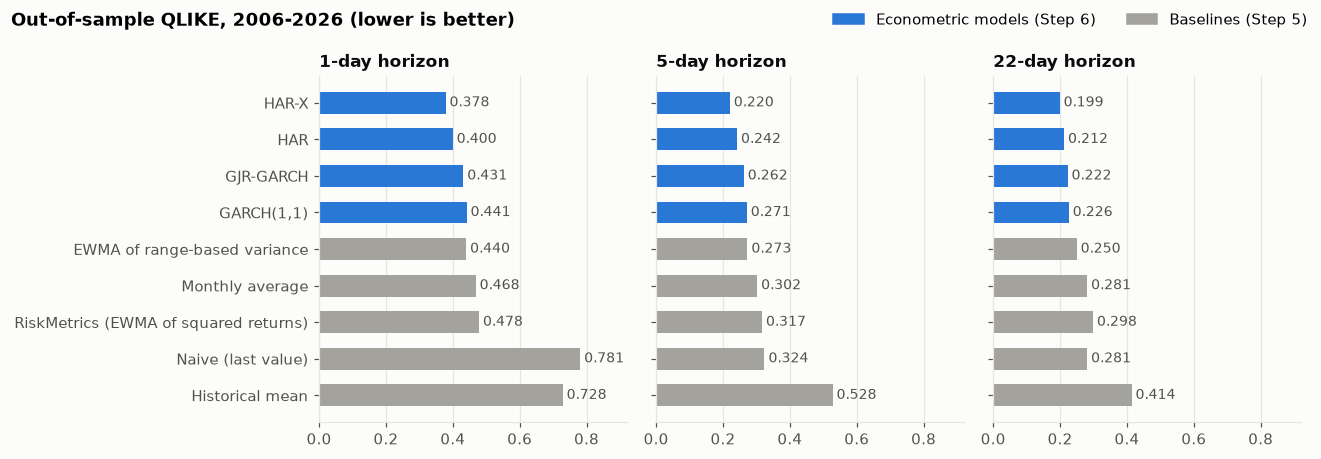

In [10]:
family = overall.drop_duplicates("model_label").set_index("model_label")["family"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharex=True)
order = table("qlike").index[::-1]
for ax, h in zip(axes, [1, 5, 22]):
    scores = overall[overall["horizon"] == h].set_index("model_label").loc[order, "qlike"]
    colors = [BLUE if family[m] == "econometric" else MUTED for m in scores.index]
    ax.barh(scores.index, scores.values, color=colors, height=0.6)
    for y, v in enumerate(scores.values):
        ax.text(v + 0.012, y, f"{v:.3f}", va="center", color=INK_2, fontsize=9)
    ax.set_title(f"{h}-day horizon", fontsize=11)
    ax.grid(axis="y", visible=False)
    if h != 1:
        ax.set_yticklabels([])
axes[0].set_xlim(0, overall["qlike"].max() * 1.18)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (BLUE, MUTED)]
fig.legend(handles, ["Econometric models (Step 6)", "Baselines (Step 5)"], loc="upper right", ncols=2)
fig.suptitle("Out-of-sample QLIKE, 2006-2026 (lower is better)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "06_model_scores")
plt.show()

In [11]:
best_baseline = overall[overall["model"] == "ewma"].set_index("horizon")["qlike"]
gain = overall[overall["family"] == "econometric"].pivot(index="model_label", columns="horizon", values="qlike")
gain = (1 - gain / best_baseline).sort_values(5, ascending=False)
gain.columns = [f"{h} day" + ("s" if h > 1 else "") for h in gain.columns]
display(gain.map("{:+.1%}".format).rename_axis("QLIKE reduction vs EWMA (best baseline)"))

,1 day,5 days,22 days
QLIKE reduction vs EWMA (best baseline),,,
HAR-X,+14.0%,+19.2%,+20.4%
HAR,+9.1%,+11.4%,+15.2%
GJR-GARCH,+1.9%,+4.0%,+10.9%
"GARCH(1,1)",-0.3%,+0.7%,+9.5%


**Reading the results.**

* **HAR-X is the best model so far** at every horizon, followed by HAR. Both beat the best baseline (EWMA) clearly.
* **GARCH is about as good as EWMA** at 1 and 5 days, and better at 22 days, where its mean reversion helps. Adding the leverage effect (GJR-GARCH) improves it at every horizon.
* **On the mean absolute error the picture is less clear-cut:** at 22 days EWMA has a slightly lower MAE than GARCH, GJR-GARCH and HAR. As seen above, MAE rewards forecasts of the median, and these models are built to forecast the mean. HAR-X is the best on both losses.

### What matters more: the model or the measurement?

Four of the models form a 2 × 2 design: the variance is measured either from squared returns or from the intraday range, and the weights are either fixed or estimated.

In [12]:
q5 = overall[overall["horizon"] == 5].set_index("model")["qlike"]
design = pd.DataFrame(
    {"fixed weights": [q5["riskmetrics"], q5["ewma"]], "estimated weights": [q5["garch"], q5["har"]]},
    index=["squared returns  (RiskMetrics -> GARCH)", "range-based variance  (EWMA -> HAR)"])
design["gain from estimation"] = (1 - design["estimated weights"] / design["fixed weights"]).map("{:.0%}".format)
print("QLIKE at the 5-day horizon")
display(design)
print(f"Gain from the range-based measure, fixed weights:     {1 - q5['ewma'] / q5['riskmetrics']:.0%}")
print(f"Gain from the range-based measure, estimated weights: {1 - q5['har'] / q5['garch']:.0%}")

QLIKE at the 5-day horizon


,fixed weights,estimated weights,gain from estimation
squared returns (RiskMetrics -> GARCH),0.317,0.271,14%
range-based variance (EWMA -> HAR),0.273,0.242,11%


Gain from the range-based measure, fixed weights:     14%
Gain from the range-based measure, estimated weights: 11%


Both dimensions help, and they add up: a better **measurement** of volatility and **estimated** weights each lower the loss by roughly 10 to 15%. A simple rule applied to a good volatility measure (EWMA) is as accurate as an estimated model applied to a noisy one (GARCH). In this project, **data quality is worth as much as model sophistication**.

## 5. Calm and stress periods, stocks and indices

In [13]:
stress = " OR ".join(f"f.date BETWEEN '{start}' AND '{end}'" for start, end in CRISES.values())
regimes = pd.read_sql(f"""
    WITH joined AS (
        SELECT f.model, f.pred_var::float8 AS forecast, exp(x.target_5d) AS actual,
               CASE WHEN {stress} THEN 'stress periods' ELSE 'calm periods' END AS regime,
               count(*) OVER (PARTITION BY f.ticker, f.date) AS models_with_forecast
        FROM forecasts_long f JOIN features x USING (ticker, date)
        WHERE f.horizon = 5
    )
    SELECT model, regime, count(*) AS n, avg(actual / forecast - ln(actual / forecast) - 1) AS qlike
    FROM joined
    WHERE actual IS NOT NULL AND models_with_forecast = (SELECT count(*) FROM models)
    GROUP BY model, regime""", engine)
by_type = pd.read_sql("""
    SELECT s.model, u.asset_type, sum(s.qlike * s.n) / sum(s.n) AS qlike
    FROM model_scores s JOIN universe u USING (ticker)
    WHERE s.horizon = 5 GROUP BY s.model, u.asset_type""", engine)

breakdown = (regimes.pivot(index="model", columns="regime", values="qlike")
             .join(by_type.pivot(index="model", columns="asset_type", values="qlike")[["stock", "index"]])
             .rename(index=LABELS, columns={"stock": "stocks", "index": "indices"}))
print("QLIKE at the 5-day horizon")
display(breakdown.sort_values("calm periods"))

QLIKE at the 5-day horizon


,calm periods,stress periods,stocks,indices
model,,,,
HAR-X,0.225,0.200,0.228,0.179
HAR,0.246,0.226,0.249,0.202
GJR-GARCH,0.260,0.270,0.271,0.213
"GARCH(1,1)",0.263,0.305,0.278,0.233
EWMA of range-based variance,0.267,0.297,0.279,0.237
Monthly average,0.298,0.317,0.309,0.262
RiskMetrics (EWMA of squared returns),0.309,0.350,0.329,0.246
Naive (last value),0.337,0.271,0.338,0.243
Historical mean,0.480,0.725,0.528,0.525


* **HAR-X is the best model in both regimes** and for both stocks and indices. In stress periods it also beats the naive forecast, which was the best baseline there: it reacts quickly *and* stays accurate in calm markets.
* **The leverage effect pays off in a crisis:** GJR-GARCH is better than EWMA in stress periods, while the symmetric GARCH is not. Reacting more to falls than to rises is what helps when markets drop.

The last check is whether the forecasts are right **on average**. A value of 1 means no bias; below 1, the forecasts are too high.

In [14]:
bias_models = ["ewma", "garch", "gjr_garch", "har", "har_x"]
bias = pd.read_sql(
    "SELECT u.asset_type, " + ", ".join(f"avg(exp(x.target_5d) / f.{m}) AS {m}" for m in bias_models) + """
    FROM forecasts f JOIN features x USING (ticker, date) JOIN universe u USING (ticker)
    WHERE f.horizon = 5 AND x.target_5d IS NOT NULL AND """ + " AND ".join(f"f.{m} IS NOT NULL" for m in bias_models) + """
    GROUP BY u.asset_type""", engine)
print("Average of actual / forecast, 5-day horizon")
display(bias.set_index("asset_type").T.rename(index=LABELS)[["stock", "index"]])

Average of actual / forecast, 5-day horizon


asset_type,stock,index
EWMA of range-based variance,1.119,1.093
"GARCH(1,1)",1.082,0.853
GJR-GARCH,1.081,0.872
HAR,1.033,0.879
HAR-X,1.061,0.945


* For **stocks**, the estimated models are close to 1.
* For **indices**, GARCH and HAR forecasts are 12 to 15% too high on average. Two different reasons: GARCH is fed with close-to-close returns, whose variance is higher than the range-based target for indices (Step 4); HAR is one regression for all series, dominated by the 50 stocks. HAR-X is closer to 1 because it knows the long-run level of each series.
* This is a limitation of pooled linear models, and a lead for Step 7: a tree-based model can treat indices and stocks differently.

## 6. What the forecasts look like

Five-day-ahead forecasts for the CAC 40 around the COVID-19 crash.

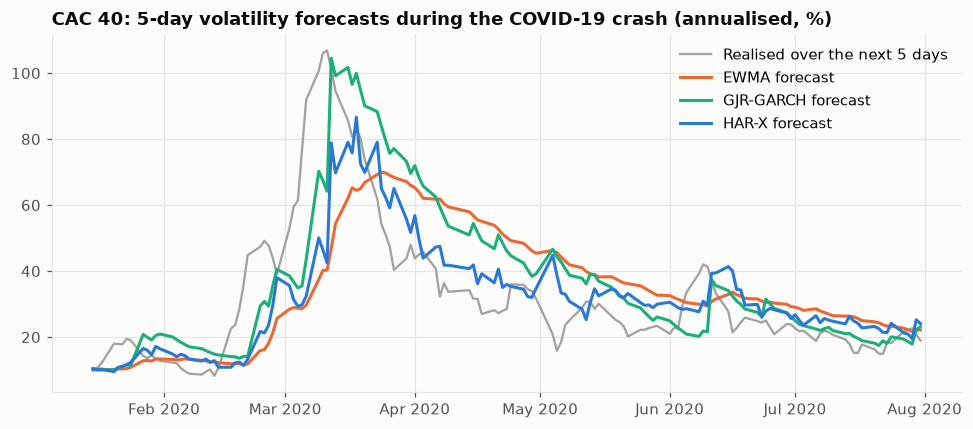

In [15]:
example = pd.read_sql("""
    SELECT model, date, pred_vol_pct, actual_vol_pct FROM forecast_vs_actual
    WHERE ticker = '^FCHI' AND horizon = 5 AND date BETWEEN '2020-01-15' AND '2020-07-31'
      AND model IN ('ewma', 'gjr_garch', 'har_x')""", engine, parse_dates=["date"])
actual = example[example["model"] == "ewma"].set_index("date")["actual_vol_pct"].sort_index()
pred = example.pivot(index="date", columns="model", values="pred_vol_pct").sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(actual.index, actual, color=MUTED, lw=1.5, label="Realised over the next 5 days")
for model, color in [("ewma", ORANGE), ("gjr_garch", AQUA), ("har_x", BLUE)]:
    ax.plot(pred.index, pred[model], color=color, lw=2, label=f"{LABELS[model].split(' of ')[0]} forecast")
ax.set_title("CAC 40: 5-day volatility forecasts during the COVID-19 crash (annualised, %)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(loc="upper right")
fig.tight_layout()
save(fig, "06_forecast_example")
plt.show()

HAR-X rises earlier than EWMA at the start of the crash (it sees the falling market, the VIX and the other European stocks) and comes down faster afterwards. GJR-GARCH reacts the most to the large falls of March, but stays too high for several weeks after the peak.

## 7. Why HAR-X becomes the benchmark

From Step 7 on, every new model (LightGBM, the LSTM, the Transformer, the combinations, and the Value-at-Risk of Step 10) is judged **against HAR-X**, not against a baseline. Four reasons:

1. **It is the best model without machine learning.** The tables above show it: HAR-X beats the baselines, GARCH, GJR-GARCH and HAR at every horizon, in calm and in stress periods, for stocks and for indices. Beating a weak model proves little: HAR-X already beats the best baseline by 14 to 20%, so any reasonable new model will too, and a comparison with a baseline would make every one of them look like a breakthrough. The question that matters is whether machine learning adds anything **to the best classical tool**.
2. **The next models start from the same information.** LightGBM receives the features of HAR-X (plus the day of the week and a stock / index flag), and the neural networks contain a HAR-X regression to which they add the raw history of the last 22 days. The gap with HAR-X then measures what the **algorithm** adds (non-linear effects, interactions, sequences), not extra data.
3. **It is the standard benchmark of the field.** The HAR model (Corsi, 2009) is the usual reference in volatility forecasting, so results expressed against it can be read by anyone who knows the literature.
4. **It is the cheap, transparent alternative.** HAR-X is estimated in seconds and has 18 coefficients that can be read and explained. A more complex model costs hours of training and is harder to validate and to explain; it has to earn that cost by beating HAR-X.

Choosing a reference changes how the results are **expressed**, not the results themselves: "2% better than HAR-X" divides the QLIKE of every model by the same number, so the ranking is exactly the one of the raw QLIKE.

## Summary

* **Four estimated models** were added to the framework: GARCH and GJR-GARCH (one per series, maximum likelihood on returns) and HAR and HAR-X (pooled linear regressions on the features of Step 4). Their forecasts are in `forecasts`, their parameters in `model_parameters`.
* **HAR-X is the new model to beat**; it lowers QLIKE by 14 to 20% compared with the best baseline. It is the benchmark of all the following steps (section 7 explains why).
* **Measurement and estimation matter equally:** the range-based variance of Step 4 brings as much as estimating the model.
* **Leverage effect confirmed:** in GJR-GARCH, falls move the variance far more than rises; in HAR-X, negative returns raise the forecast.
* **Forecasting a variance from a model of its logarithm requires a correction factor**, otherwise risk is under-predicted on average.

Next: Step 7 tests whether a non-linear model (LightGBM) can extract more from the same features than the linear HAR-X.